# Case 7

# Streaming points/windows to MLP-VAE with/without cyclic time features

## Purpose of this notebook

This notebook demonstrates one of the central observations of the thesis:

> A contextual anomaly — a value that looks plausible in isolation but is abnormal for the season — is invisible to a model that only ever sees one isolated timestep. Window mode, which gives the model a stretch of recent history to compare against, is what actually exposes the pattern.

The thesis studies anomaly detection in streaming ERA5 weather data. It compares the impact of different configurations (VAE architecture, streaming mode, feature manipulation methods) on VAEs with different deep learning models as encoder/decoder.

This testcase focuses on **contextual anomalies** and **MLP-VAE only** — plain and with cyclic time features reconstructed ("MLP-VAE-Cyclic"). LSTM-VAE and Transformer-VAE are not included: both are designed to process a window of consecutive timesteps (a recurrent hidden state or self-attention needs more than one timestep to do anything useful), so streaming them in point mode (`T=1`) forces a degenerate case they were never built for rather than a fair comparison. See the note in Scope below.

---

For the complete experiment definitions, consult the thesis section associated with **4.4.1 Effect of Stream Mode: Point vs. Window**, together with the YAML configuration files used by this suite.

## What is being compared?

The notebook runs four variants of MLP-VAE — two streaming modes, each with and without cyclic-feature reconstruction:

| Variant | Stream mode | Cyclic features reconstructed? | Meaning |
|---|---|---:|---|
| **MLP-VAE, point** | Point (`T=1`) | No | Sees one isolated timestep at a time — no temporal context at all. |
| **MLP-VAE, window** | Window (`T=seq_len`) | No | Sees a stretch of recent history — can compare the current value against its recent trend. |
| **MLP-VAE-Cyclic, point** | Point (`T=1`) | Yes | No temporal context, but explicit hour-of-day/day-of-year phase is supplied and reconstructed. |
| **MLP-VAE-Cyclic, window** | Window (`T=seq_len`) | Yes | Both temporal context and explicit calendar phase. |

Comparing point vs. window within each cyclic setting isolates the effect of streaming granularity; comparing plain vs. cyclic within each stream mode isolates the effect of explicit calendar phase — including whether cyclic features can substitute for the temporal context that point mode lacks.

## Findings being illustrated

The thesis confirms that window mode is far stronger than point mode at detecting contextual anomalies for MLP-VAE. A seasonal mismatch can only be recognised by comparing a value against its recent trend — something a single isolated timestep cannot provide. As MLP-VAE lacks recurrence, cyclic time features partially recovers point-mode performance (an explicit phase signal acts as a substitute for temporal context), but window mode remains far stronger even with cyclic features included.

This reduced notebook uses the full-scale ERA5 export by default (see `case01_clean_baseline.ipynb` for why), so results should be directionally close to the thesis, though exact metric values are not expected to match (single seed, this repo's own port of the training code). The important result is the **relative pattern**: window mode should clearly outperform point mode in both the plain and cyclic settings, and cyclic features should narrow (without closing) that gap in point mode.

---

## What this notebook will do

1. Check whether a GPU is available.
2. Clone and install the thesis repository.
3. Run the four point/window × plain/cyclic variants on the same contextual-anomaly dataset.
4. Collect F1, AUC, precision, recall, and confusion-matrix counts.
5. Plot F1 across the four variants.

### Expected runtime

Window-mode runs are batched and use the GPU when available. Point-mode runs stream one gradient step per row with no batching, so they run on CPU instead (faster than GPU for this access pattern) and take longer — `modules/stream/point.yaml` caps them to a subset of the test set for this reason.

### Before running

This notebook reads code and data from a **private GitHub repository**. You must:

1. Have permission to access the read-only repository with a fine-grained GitHub token.
2. In Colab, open the **Secrets** panel using the key icon.
3. Add the secret `GITHUB_TOKEN`.
4. Enable **Notebook access** for that secret.
5. Select **Runtime → Change runtime type → GPU**.
6. Choose **Runtime → Run all**.

The source ERA5 data and its licence information are described in `DATA_LICENSE.md`.

# Run Case

### Check GPU availability

In [1]:
%matplotlib inline
import torch

print("Environment check")
print("-----------------")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Selected device:", torch.cuda.get_device_name(0))
else:
    print(
        "No GPU was detected. The notebook can still run, but "
        "window-based training may be slower."
    )


Environment check
-----------------
PyTorch version: 2.10.0+cu126
CUDA available: True
Selected device: Quadro RTX 6000


### Import and/or load Repo

In [2]:
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/hadasecohen/streaming-vae-anomaly-detection.git"
REPO_DIR = Path("/content/repo") if "COLAB_RELEASE_TAG" in os.environ else Path("repo")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import userdata

    token = userdata.get("GITHUB_TOKEN")
    if not token:
        raise RuntimeError(
            "The Colab secret GITHUB_TOKEN is unavailable. "
            "Open the key icon in the left sidebar, add the token, "
            "and enable Notebook access."
        )

    if not REPO_DIR.exists():
        # Use an askpass helper so the token is not stored in the Git remote URL.
        askpass = Path("/content/git_askpass.sh")
        askpass.write_text(
            '#!/bin/sh\n'
            'case "$1" in\n'
            '  *Username*) echo "x-access-token" ;;\n'
            '  *Password*) echo "$GITHUB_TOKEN" ;;\n'
            'esac\n'
        )
        askpass.chmod(0o700)

        env = os.environ.copy()
        env["GITHUB_TOKEN"] = token
        env["GIT_ASKPASS"] = str(askpass)
        env["GIT_TERMINAL_PROMPT"] = "0"

        try:
            subprocess.run(
                ["git", "clone", REPO_URL, str(REPO_DIR)],
                check=True,
                env=env,
            )
        finally:
            askpass.unlink(missing_ok=True)

    os.chdir(REPO_DIR)
else:
    # When launched from notebooks/cases inside a local checkout,
    # move to the repository root.
    if not Path("scripts/run_regression.py").exists():
        os.chdir("../..")

print("Working directory:", os.getcwd())
print("Installing the project dependencies...")
subprocess.run(
    ["python", "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    check=True,
)
%env MPLBACKEND=Agg
print("Setup complete.")


Working directory: .
Installing the project dependencies...
env: MPLBACKEND=Agg
Setup complete.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


### Step 1 — Configure the run

In [3]:
import os
import yaml

CASE_ID = "case07_point_vs_window"
SESSION_DIR = "runs/regression"
OUTPUT_DIR = f"{SESSION_DIR}/{CASE_ID}"

# Edit this directly — works the same locally and on Colab:
#   "full_split_files" (default) -> anom_types/contextual.yaml's own default —
#                      full-scale contextual data, pre-split into a
#                      warmup-only file (shared with case01 — the warmup
#                      portion is anomaly-free and identical regardless of
#                      anomaly type) and a test-only file with the
#                      contextual anomalies injected. Committed to the repo.
#   "mini_50pct"    -> the in-repo 377,784-row ERA5 slice (~50% of full-scale).
#                      Committed to the repo.
#   "mini_28pct"    -> the in-repo 210,384-row ERA5 slice (~28% of full-scale).
#                      Committed to the repo.
DATA_SOURCE = "full_split_files"

_DATA_SOURCE_LAYERS = {
    "full_split_files": None,   # anom_types/contextual.yaml's own default — no extra layer needed
    "mini_50pct": "../../modules/data_source/mini_50pct_contextual.yaml",
    "mini_28pct": "../../modules/data_source/mini_28pct_contextual.yaml",
}

_suite_source_path = f"notebooks/cases/{CASE_ID}_suite.yaml"
_suite_dir = os.path.dirname(os.path.abspath(_suite_source_path))

def _resolve(path):
    # base_config / config_layers entries are relative paths meant to be
    # read relative to the suite file's own directory (notebooks/cases/).
    # Resolving them to absolute paths here — rather than leaving them
    # relative — means the resolved copy stays correct no matter how deep
    # under OUTPUT_DIR it ends up being written.
    return path if os.path.isabs(path) else os.path.normpath(os.path.join(_suite_dir, path))

_data_source_layer = _DATA_SOURCE_LAYERS[DATA_SOURCE]

with open(_suite_source_path) as f:
    _suite = yaml.safe_load(f)

_suite["base_config"] = _resolve(_suite["base_config"])
for _run in _suite["runs"]:
    _layers = [_resolve(p) for p in _run["config_layers"]]
    if _data_source_layer:
        _layers.append(_resolve(_data_source_layer))
    _run["config_layers"] = _layers

# Written under OUTPUT_DIR (runs/, already gitignored and read-write) rather
# than notebooks/ (source-controlled, meant to stay read-only) — os.makedirs
# because OUTPUT_DIR won't exist yet on a fresh run.
os.makedirs(OUTPUT_DIR, exist_ok=True)
SUITE_PATH = f"{OUTPUT_DIR}/{CASE_ID}_suite_resolved.yaml"
with open(SUITE_PATH, "w") as f:
    yaml.safe_dump(_suite, f, sort_keys=False)

print(f"DATA_SOURCE = {DATA_SOURCE!r} -> {_data_source_layer}")

DATA_SOURCE = 'full_split_files' -> None


#### Configuration file

The notebooks test suites combines a shared ERA5 configuration (`modules/era5_common.yaml`) with the architecture, anomaly type, stream mode, and cyclic-feature settings for each run.

`DATA_SOURCE` may be configured to choose other datasets from the era5 data directory.
The default is `"full_split_files"`, which is the full-scale contextual-anomaly data, where warmup and test files are split (`data/era5/full_scale/split/era5_clean_warmup.csv` and `data/era5/full_scale/split/era5_contextual_test.csv`).

All variants use the same base configuration and evaluation procedure. The intended comparison is therefore the effect of **streaming granularity (point vs. window)** and **cyclic-feature reconstruction** on MLP-VAE's contextual-anomaly detection.

#### Output Directory

During execution, the script creates a separate run directory in the repo for each variant under `OUTPUT_DIR` (`runs/regression/case07_point_vs_window` by default).

`notebooks/cases/case07_point_vs_window_suite.yaml` layers `modules/era5_common.yaml` with the architecture / anomaly-type / stream-mode / feature-engineering fragments for each of the runs below (see the suite file for the exact overrides).

### Step 2 Run the testsuite

### Command:

In [4]:
!python scripts/run_regression.py {SUITE_PATH} \
    --session {SESSION_DIR} --skip-existing

[suite] log     : runs/regression/suite.log
[suite] suite   : runs/regression/case07_point_vs_window/case07_point_vs_window_suite_resolved.yaml
[suite] session : runs/regression
[suite] base cfg: modules/era5_common.yaml
[suite] module  : regression.run_trial
[suite] GPUs    : [0, 1, 2]  (3 slot(s))
[suite] 4 run(s) planned:
  [  1] MLP_plain_point  [case07_point_vs_window/case07_point_vs_window_suite_resolved]  (module: regression.run_trial)
  [  2] MLP_plain_window  [case07_point_vs_window/case07_point_vs_window_suite_resolved]  (module: regression.run_trial)
  [  3] MLP_cyclic_point  [case07_point_vs_window/case07_point_vs_window_suite_resolved]  (module: regression.run_trial)
  [  4] MLP_cyclic_window  [case07_point_vs_window/case07_point_vs_window_suite_resolved]  (module: regression.run_trial)
[suite] --skip-existing: completed runs will be skipped
[suite] START  'MLP_cyclic_point'  (CPU)
[suite] START  'MLP_plain_point'  (CPU)
[suite] START  'MLP_cyclic_window'  (GPU=0)
[suite] 

### Step 3 — Build a common comparison

#### The next command reads the predictions from every run and produces:

- a common performance table
- anomaly-score histograms
- an F1 comparison across variants
- confusion-matrix summaries
- seed-stability diagnostics, where applicable.

These outputs are saved under `OUTPUT_DIR/cross_compare/`.

### Command:

In [4]:
!python scripts/cross_compare.py {OUTPUT_DIR}

[cross] session : runs/regression/case07_point_vs_window
[cross] output  : runs/regression/case07_point_vs_window/cross_compare
[cross] 4 run(s) found:
  MLP_Cyclic_Contextual_point                         arch=MLP_Cyclic  anomaly=Contextual  cyclic=False  mode=window
  MLP_Cyclic_Contextual_window                        arch=MLP_Cyclic  anomaly=Contextual  cyclic=False  mode=window
  MLP_Contextual_point                                arch=MLP  anomaly=Contextual  cyclic=False  mode=window
  MLP_Contextual_window                               arch=MLP  anomaly=Contextual  cyclic=False  mode=window

[cross] Loading run data ...
  MLP_Cyclic_Contextual_point ... ok
  MLP_Cyclic_Contextual_window ... ok
  MLP_Contextual_point ... ok
  MLP_Contextual_window ... ok

[cross] Writing outputs ...
  saved performance_table.csv
  saved performance_summary.txt

  ══ Contextual anomalies ══════════════════════════════════════════════════════════════════════════════════════════
  run_name         

### Step 4 — Quantitative Results

### Command:

In [5]:
import pandas as pd
from IPython.display import display

performance_path = f"{OUTPUT_DIR}/cross_compare/performance_table.csv"
perf = pd.read_csv(performance_path)

columns = [
    "run_name", "arch", "anomaly", "variant",
    "f1", "auc", "precision", "recall",
    "tp", "fp", "fn",
]

print("Comparison of point-vs-window / plain-vs-cyclic variants")
display(
    perf[columns]
    .sort_values("run_name")
    .reset_index(drop=True)
    .style.format({
        "f1": "{:.3f}",
        "auc": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
    })
)

Comparison of point-vs-window / plain-vs-cyclic variants


,run_name,arch,anomaly,variant,f1,auc,precision,recall,tp,fp,fn
0,MLP_Contextual_point,MLP,Contextual,point,0.072,0.747,0.095,0.058,616,5851,9968
1,MLP_Contextual_window,MLP,Contextual,window,0.485,0.907,0.625,0.396,347,208,530
2,MLP_Cyclic_Contextual_point,MLP_Cyclic,Contextual,point,0.250,0.807,0.220,0.291,3076,10917,7508
3,MLP_Cyclic_Contextual_window,MLP_Cyclic,Contextual,window,0.728,0.956,0.764,0.696,610,188,267


#### Focus first on `f1`, `precision`, and `recall`. These are the main thesis metrics:

- higher **precision** means fewer normal observations were falsely flagged;
- higher **recall** means more contextual anomalies were detected;
- `tp`, `fp`, and `fn` show the corresponding counts.

#### Expected pattern

```text
Plain:  F1(point)  <<  F1(window)     (window far ahead — point mode has no temporal context)
Cyclic: F1(point)  <   F1(window)     (cyclic narrows the gap, but window still wins)
```

The testcase is successful when window mode clearly outperforms point mode in both the plain and cyclic settings, and the plain-point F1 is the weakest of the four, even if the exact values differ from the thesis.

### Step 5 — Qualitative support (Plots)

#### F1 by stream mode and cyclic setting

##### Command:

  saved runs/regression/case07_point_vs_window/cross_compare/bars_plain_f1_contextual.png
  saved runs/regression/case07_point_vs_window/cross_compare/bars_cyclic_f1_contextual.png


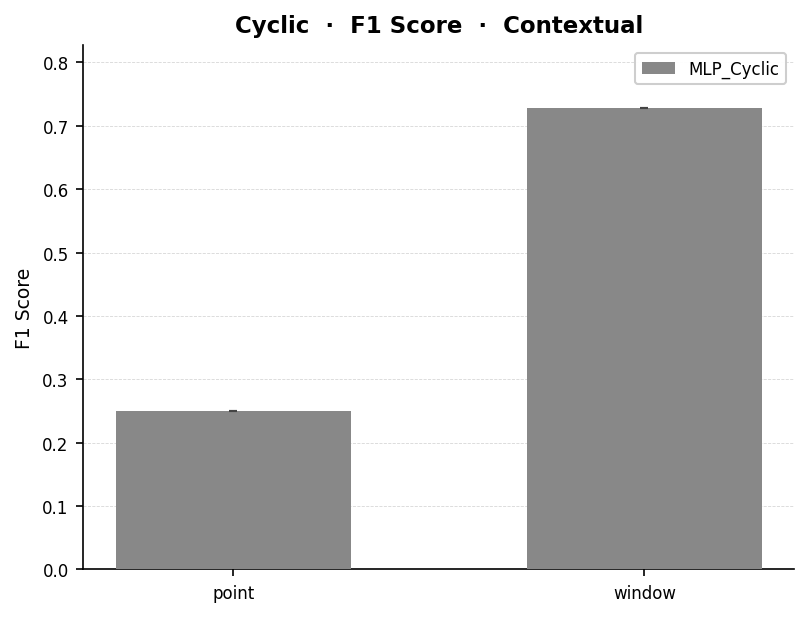

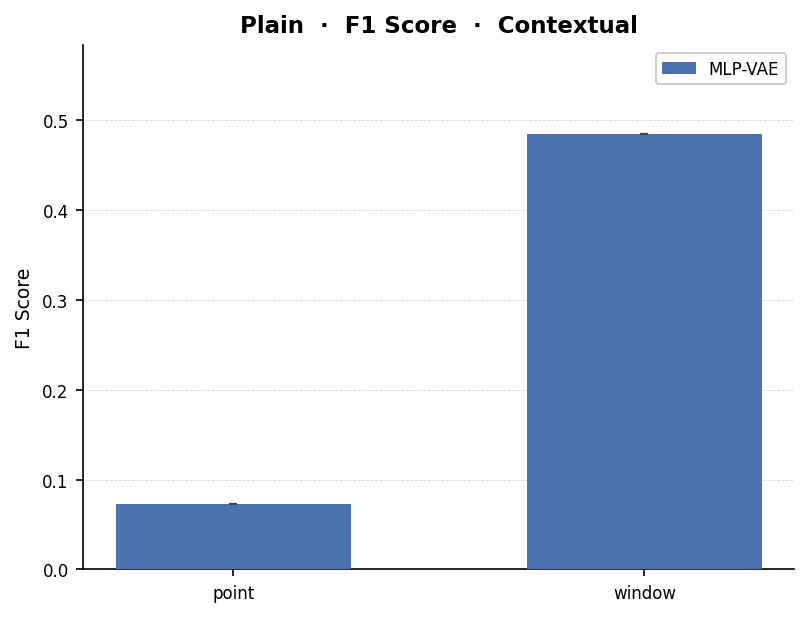

In [6]:
!python scripts/plot_categorical_bars.py {OUTPUT_DIR} --section plain --metric f1
!python scripts/plot_categorical_bars.py {OUTPUT_DIR} --section cyclic --metric f1

import glob
from IPython.display import Image, display

for p in sorted(glob.glob(f"{OUTPUT_DIR}/cross_compare/bars_*_f1_*.png")):
    display(Image(filename=p))

Two bar charts — one for the plain setting (no cyclic features), one for the cyclic setting — each comparing F1 for point vs. window mode.

#### Score histograms by stream mode

##### Command:

Score histograms (normal vs anomaly), one file per architecture:


MLP,MLP_Cyclic

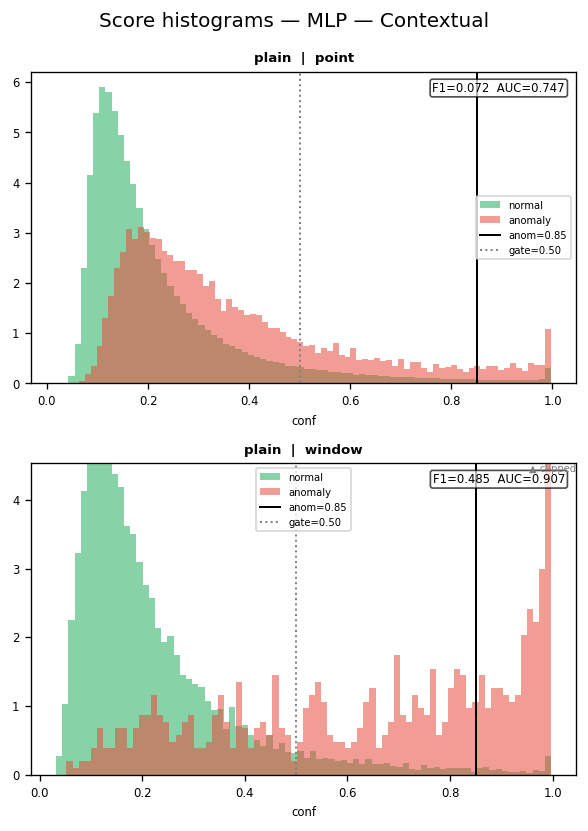
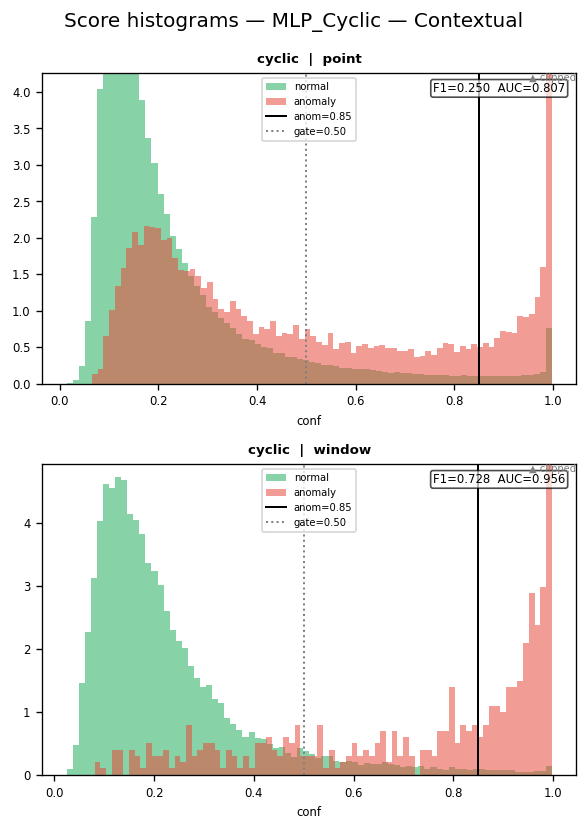

In [5]:
# Display the key comparison plot(s) inline, 2 per row, captioned by filename
import base64
import glob
from IPython.display import HTML, display

paths = sorted(glob.glob(f"{OUTPUT_DIR}/cross_compare/contextual/score_hist_*.png"))
print("Score histograms (normal vs anomaly), one file per architecture:")

n_cols = 2
rows_html = []
for i in range(0, len(paths), n_cols):
    row_paths = paths[i:i + n_cols]
    cells = []
    for path in row_paths:
        # caption from the filename (score_hist_{arch}.png), not the image
        # pixels — reliable because cross_compare.py names the file after
        # the architecture it plots.
        label = path.split("/")[-1].removeprefix("score_hist_").removesuffix(".png")
        with open(path, "rb") as f:
            b64 = base64.b64encode(f.read()).decode("ascii")
        cells.append(
            f'<td style="width:{100 // n_cols}%; padding:4px; text-align:center; vertical-align:top;">'
            f'<div style="font-weight:600; margin-bottom:4px;">{label}</div>'
            f'<img src="data:image/png;base64,{b64}" style="max-width:100%;"></td>'
        )
    rows_html.append("<tr>" + "".join(cells) + "</tr>")

display(HTML(f'<table style="width:100%; border-collapse:collapse;">{"".join(rows_html)}</table>'))

Better separation between the normal (green) and anomaly (red) distributions in window mode than in point mode is what should drive the F1 differences in the table above.

#### The plots can indicate, among other things:

1. Whether window mode shows meaningfully better-separated score distributions than point mode.
2. Whether cyclic-feature reconstruction narrows that separation gap in point mode.
3. Whether window mode's advantage is driven more by precision, recall, or both.

### Main takeaway

A contextual anomaly is defined by its relationship to recent history and calendar context, not by its value in isolation — so a model that only ever sees one timestep at a time has no way to recognise one. Window mode gives MLP-VAE the temporal context it needs to compare a value against its recent trend, which is why it substantially outperforms point mode. Reconstructing cyclic time features supplies an explicit substitute for some of that missing context and narrows the gap, but does not close it — window mode remains the stronger streaming granularity for this anomaly type.

## Scope of this testcase

This notebook is a compact demonstration, not a full reproduction of every point-vs-window experiment reported in the thesis. With `DATA_SOURCE = "full_split_files"` (the default) it runs on the full-scale contextual-anomaly data. With `DATA_SOURCE = "mini_50pct"` / `"mini_28pct"` a shorter ERA5 interval is used instead — useful for a quick check, but see `case01_clean_baseline.ipynb` for why it can give different results than the full-scale data.

This notebook only tests MLP-VAE (plain and cyclic). LSTM-VAE and Transformer-VAE are excluded deliberately: both architectures are designed to process a window of consecutive timesteps — a recurrent hidden state needs a sequence to recur over, and self-attention needs more than one token to attend across. Streaming either of them in point mode (`T=1`) does not exercise a real capability gap the way it does for MLP-VAE; it forces a degenerate configuration neither architecture was built for; see `src/VAE/normalizing_flows.py`'s note that a `T=1` recurrent component "receives only zero context and produces a near-identity transform." A point-vs-window comparison for LSTM-VAE or Transformer-VAE would not be a meaningful test of streaming granularity in the way it is for MLP-VAE.

Conclusions should be based on the **direction and consistency of the point-vs-window gap in both the plain and cyclic settings**, rather than exact numerical agreement with the thesis figures (single seed, this repo's own port of the training code).